# VeriTriage — Feature Engineering
## Extract statistical features from 259×259 spatial maps

**Strategy:**
- INPUT features: cell_density + macro_region (placement stage)
- OUTPUT labels: IR_drop + DRC + congestion (sign-off stage)
- Extract 20+ statistical features per map per sample
- Result: one flat feature vector per chip design

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

ROOT = Path(r"C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage")

# Input features (placement stage — available BEFORE sign-off)
CD_PATH  = ROOT / "data/raw/circuitnet/IR_drop/IR_drop"
MR_PATH  = ROOT / "data/raw/circuitnet/routability/macro_region/macro_region"
CD_PATH  = ROOT / "data/raw/circuitnet/routability/cell_density/cell_density"

# Output labels (sign-off stage — what we want to predict)
IR_PATH  = ROOT / "data/raw/circuitnet/IR_drop/IR_drop"
DRC_PATH = ROOT / "data/raw/circuitnet/routability/DRC/DRC_all"
CGH_PATH = ROOT / "data/raw/circuitnet/routability/congestion/overflow_based/congestion_eGR_horizontal_overflow"
CGV_PATH = ROOT / "data/raw/circuitnet/routability/congestion/overflow_based/congestion_eGR_vertical_overflow"
MR_PATH  = ROOT / "data/raw/circuitnet/routability/macro_region/macro_region"
CD_PATH  = ROOT / "data/raw/circuitnet/routability/cell_density/cell_density"

# Get all sample names (use IR drop as reference)
all_files = sorted([f.name for f in IR_PATH.iterdir()])
print(f"Total samples: {len(all_files)}")
print(f"Example: {all_files[0]}")

Total samples: 10242
Example: 1-RISCY-a-1-c2-u0.7-m1-p1-f0


In [2]:
def extract_features(arr):
    """Extract statistical features from a 259x259 spatial map"""
    h, w = arr.shape
    mid_h, mid_w = h//2, w//2
    
    return {
        # Global statistics
        'mean':          arr.mean(),
        'std':           arr.std(),
        'max':           arr.max(),
        'min':           arr.min(),
        # Percentiles
        'p25':           np.percentile(arr, 25),
        'p50':           np.percentile(arr, 50),
        'p75':           np.percentile(arr, 75),
        'p90':           np.percentile(arr, 90),
        'p95':           np.percentile(arr, 95),
        'p99':           np.percentile(arr, 99),
        # Spatial — quadrant means
        'q_topleft':     arr[:mid_h, :mid_w].mean(),
        'q_topright':    arr[:mid_h, mid_w:].mean(),
        'q_botleft':     arr[mid_h:, :mid_w].mean(),
        'q_botright':    arr[mid_h:, mid_w:].mean(),
        # Hotspot location
        'hotspot_row':   np.unravel_index(arr.argmax(), arr.shape)[0] / h,
        'hotspot_col':   np.unravel_index(arr.argmax(), arr.shape)[1] / w,
        # Distribution shape
        'skewness':      float(pd.Series(arr.flatten()).skew()),
        'kurtosis':      float(pd.Series(arr.flatten()).kurtosis()),
        # Density thresholds
        'density_high':  (arr > arr.mean() + arr.std()).mean(),
        'density_low':   (arr < arr.mean()).mean(),
        # Energy
        'energy':        (arr**2).mean(),
    }

def parse_filename(name):
    """Extract design metadata from filename"""
    parts = name.split('-')
    return {
        'sample_name': name,
        'design':      parts[1] if len(parts) > 1 else '?',
        'variant':     parts[2] if len(parts) > 2 else '?',
        'floorplan':   parts[-1] if len(parts) > 0 else '?',
    }

# Extract features for all 10,242 samples
print("Extracting features from all samples...")
print("This takes ~5-7 minutes. Go grab a coffee.")

rows = []

for fname in tqdm(all_files):
    row = parse_filename(fname)
    
    # Load input features
    cd  = np.load(CD_PATH  / fname)
    mr  = np.load(MR_PATH  / fname)
    
    # Load labels
    ir  = np.load(IR_PATH  / fname)
    drc = np.load(DRC_PATH / fname)
    cgh = np.load(CGH_PATH / fname)
    cgv = np.load(CGV_PATH / fname)
    
    # Extract input features
    cd_feats = {f'cd_{k}': v for k, v in extract_features(cd).items()}
    mr_feats = {f'mr_{k}': v for k, v in extract_features(mr).items()}
    row.update(cd_feats)
    row.update(mr_feats)
    
    # Create labels
    IR_THRESHOLD  = 5.0    # mV — IR drop violation
    DRC_THRESHOLD = 0.0    # any DRC violation = fail
    CG_THRESHOLD  = 0.0    # any congestion overflow = fail
    
    row['ir_max']          = ir.max()
    row['drc_count']       = (drc > DRC_THRESHOLD).sum()
    row['cg_overflow']     = max(cgh.max(), cgv.max())
    
    # Binary triage labels — FAIL=1, PASS=0
    row['label_ir']        = int(ir.max()  > IR_THRESHOLD)
    row['label_drc']       = int(drc.max() > DRC_THRESHOLD)
    row['label_cg']        = int(max(cgh.max(), cgv.max()) > CG_THRESHOLD)
    
    rows.append(row)

df = pd.DataFrame(rows)

print(f"\nFeature matrix shape: {df.shape}")
print(f"\nLabel distribution:")
print(f"  IR drop  FAIL: {df.label_ir.sum():5d} ({df.label_ir.mean()*100:.1f}%)")
print(f"  DRC      FAIL: {df.label_drc.sum():5d} ({df.label_drc.mean()*100:.1f}%)")
print(f"  Congestion FAIL: {df.label_cg.sum():5d} ({df.label_cg.mean()*100:.1f}%)")

# Save
out = ROOT / "data/processed"
out.mkdir(parents=True, exist_ok=True)
df.to_csv(out / "veritriage_features.csv", index=False)
print(f"\nSaved to data/processed/veritriage_features.csv")

Extracting features from all samples...
This takes ~5-7 minutes. Go grab a coffee.


100%|██████████| 10242/10242 [12:56<00:00, 13.19it/s]



Feature matrix shape: (10242, 52)

Label distribution:
  IR drop  FAIL:  4507 (44.0%)
  DRC      FAIL: 10242 (100.0%)
  Congestion FAIL: 10233 (99.9%)

Saved to data/processed/veritriage_features.csv


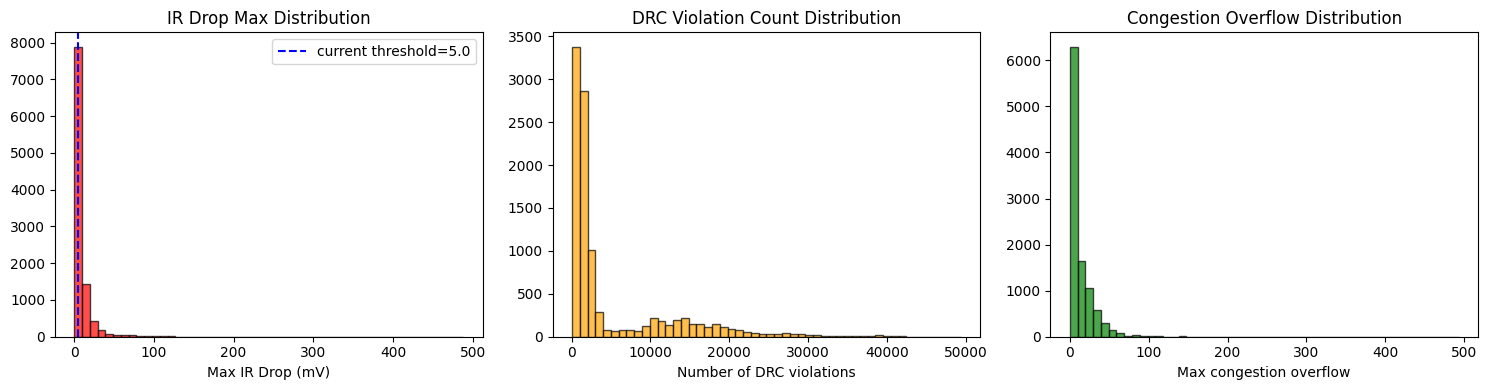

IR Drop percentiles:
  50th: 4.068 mV
  75th: 9.212 mV
  90th: 18.460 mV
  95th: 29.125 mV
  99th: 83.075 mV

DRC count percentiles:
  50th: 1509.5 violations
  75th: 6314.5 violations
  90th: 16502.7 violations
  95th: 20636.0 violations
  99th: 31205.6 violations

Congestion overflow percentiles:
  50th: 3.0000
  75th: 18.0000
  90th: 32.0000
  95th: 44.0000
  99th: 84.2950


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Analyze the actual value distributions to pick better thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# IR drop
axes[0].hist(df['ir_max'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('IR Drop Max Distribution')
axes[0].set_xlabel('Max IR Drop (mV)')
axes[0].axvline(5.0, color='blue', linestyle='--', label='current threshold=5.0')
axes[0].legend()

# DRC
axes[1].hist(df['drc_count'], bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title('DRC Violation Count Distribution')
axes[1].set_xlabel('Number of DRC violations')

# Congestion
axes[2].hist(df['cg_overflow'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].set_title('Congestion Overflow Distribution')
axes[2].set_xlabel('Max congestion overflow')

plt.tight_layout()
plt.savefig(ROOT / "results/plots/02_label_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# Print percentiles to choose thresholds
print("IR Drop percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {np.percentile(df.ir_max, p):.3f} mV")

print("\nDRC count percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {np.percentile(df.drc_count, p):.1f} violations")

print("\nCongestion overflow percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {np.percentile(df.cg_overflow, p):.4f}")

In [5]:
# Fix thresholds for balanced labels
IR_THRESHOLD  = 5.0     # mV
DRC_THRESHOLD = 1500    # violation count
CG_THRESHOLD  = 3.0     # overflow value

df['label_ir']  = (df['ir_max']      > IR_THRESHOLD).astype(int)
df['label_drc'] = (df['drc_count']   > DRC_THRESHOLD).astype(int)
df['label_cg']  = (df['cg_overflow'] > CG_THRESHOLD).astype(int)

print("Updated Label Distribution:")
print(f"  IR drop    FAIL: {df.label_ir.sum():5d} ({df.label_ir.mean()*100:.1f}%) | PASS: {(df.label_ir==0).sum():5d} ({(df.label_ir==0).mean()*100:.1f}%)")
print(f"  DRC        FAIL: {df.label_drc.sum():5d} ({df.label_drc.mean()*100:.1f}%) | PASS: {(df.label_drc==0).sum():5d} ({(df.label_drc==0).mean()*100:.1f}%)")
print(f"  Congestion FAIL: {df.label_cg.sum():5d} ({df.label_cg.mean()*100:.1f}%) | PASS: {(df.label_cg==0).sum():5d} ({(df.label_cg==0).mean()*100:.1f}%)")

# Add design family column for GPU analysis later
df['chip_family'] = df['design'].apply(lambda x: 'RISCY' if x == 'RISCY' else 'zero-riscy')

print(f"\nChip families:")
print(f"  RISCY:      {(df.chip_family=='RISCY').sum()} samples")
print(f"  zero-riscy: {(df.chip_family=='zero-riscy').sum()} samples")

# Save updated CSV
df.to_csv(ROOT / "data/processed/veritriage_features.csv", index=False)
print(f"\nFinal dataset: {df.shape[0]} samples × {df.shape[1]} columns")
print("Saved!")

Updated Label Distribution:
  IR drop    FAIL:  4507 (44.0%) | PASS:  5735 (56.0%)
  DRC        FAIL:  5140 (50.2%) | PASS:  5102 (49.8%)
  Congestion FAIL:  5044 (49.2%) | PASS:  5198 (50.8%)

Chip families:
  RISCY:      7078 samples
  zero-riscy: 3164 samples

Final dataset: 10242 samples × 53 columns
Saved!
